# Fidelity heatmaps: regular vs physicless

Mean fidelity on the same ID-test Hamiltonian/state pairs. No training or inference is performed.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from os import listdir

In [2]:
ROOT = Path().cwd().parent

In [3]:
MODE, REGULAR_ROUTE = "DEVELOPMENT", "direct_topology"  # or: FULL; initial_ritz
file = "per_state_output_metrics.csv"
latest = lambda root, pattern: max((p for p in root.glob(pattern) if (p/file).exists()), key=lambda p: (p/file).stat().st_mtime)
regular_dir = latest(ROOT/"outputs", f"true_jepa_{MODE.lower()}_*")
physicless_dir = latest(ROOT/"physicless"/"outputs", f"physicless_jepa_{MODE.lower()}_*")
card = lambda p: json.loads((p/"run_card.json").read_text(encoding="utf-8"))
regular_card, physicless_card = card(regular_dir), card(physicless_dir)


In [15]:
assert regular_card["run_mode"] == physicless_card["run_mode"] == MODE
assert regular_card["split_manifest_hash"] == physicless_card["split_manifest_hash"]

AssertionError: 

In [4]:
def load(run, route, model):
    d = pd.read_csv(run/file).query("category == 'ID_test' and output_route == @route")
    return d.groupby(["family", "state"]).fidelity.agg(["mean", "std", "count"]).reset_index().assign(model=model)

data = pd.concat([load(regular_dir, REGULAR_ROUTE, "Regular"), load(physicless_dir, "direct_unconstrained", "Physicless")], ignore_index=True)
order = data.query("model == 'Regular'").groupby("family")["mean"].mean().sort_values(ascending=False).index
maps = {m: data.query("model == @m").pivot(index="state", columns="family", values="mean").reindex(columns=order) for m in ("Regular", "Physicless")}
out_metrics = ROOT/"results"/"01_metrics"; out_figures = ROOT/"results"/"02_figures"/"ablation"
out_metrics.mkdir(parents=True, exist_ok=True); out_figures.mkdir(parents=True, exist_ok=True)
data.rename(columns={"state": "n", "mean": "mean_fidelity", "std": "std_fidelity"}).to_csv(out_metrics/"fidelity_heatmap_regular_vs_physicless.csv", index=False)


In [5]:
plt.rcParams.update({"font.family": "serif", "font.size": 8, "axes.linewidth": .8})

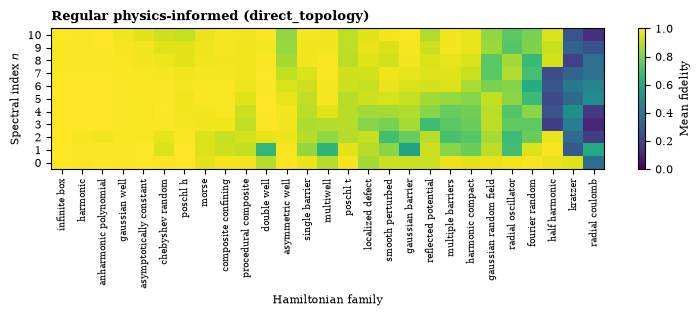

In [6]:
model, title = "Regular", f"Regular physics-informed ({REGULAR_ROUTE})"
fig, ax = plt.subplots(figsize=(max(7.2, .28*len(order)), 3.2))
im = ax.imshow(maps[model].to_numpy(), origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set(ylabel=r"Spectral index $n$", yticks=range(len(maps[model].index)), yticklabels=maps[model].index,
       xticks=range(len(order)), xticklabels=[x.replace("_", " ") for x in order], xlabel="Hamiltonian family")
plt.setp(ax.get_xticklabels(), rotation=90, ha="center", fontsize=6.5)
ax.set_title(title, fontweight="bold", loc="left"); ax.grid(False)
fig.colorbar(im, ax=ax, label="Mean fidelity")
fig.tight_layout()
#fig.savefig(out_figures/"fidelity_heatmap_regular.png", dpi=600, bbox_inches="tight")
#fig.savefig(out_figures/"fidelity_heatmap_regular.pdf", bbox_inches="tight")
plt.show()

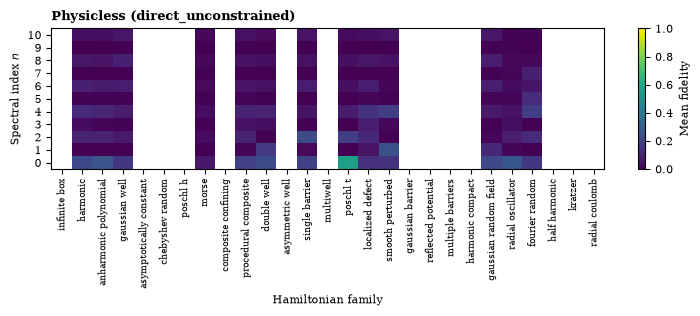

In [7]:
model, title = "Physicless", "Physicless (direct_unconstrained)"
fig, ax = plt.subplots(figsize=(max(7.2, .28*len(order)), 3.2))
im = ax.imshow(maps[model].to_numpy(), origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set(ylabel=r"Spectral index $n$", yticks=range(len(maps[model].index)), yticklabels=maps[model].index,
       xticks=range(len(order)), xticklabels=[x.replace("_", " ") for x in order], xlabel="Hamiltonian family")
plt.setp(ax.get_xticklabels(), rotation=90, ha="center", fontsize=6.5)
ax.set_title(title, fontweight="bold", loc="left"); ax.grid(False)
fig.colorbar(im, ax=ax, label="Mean fidelity")
fig.tight_layout()
#fig.savefig(out_figures/"fidelity_heatmap_physicless.png", dpi=600, bbox_inches="tight")
#fig.savefig(out_figures/"fidelity_heatmap_physicless.pdf", bbox_inches="tight")
plt.show()

In [8]:
assert maps["Regular"].shape == maps["Physicless"].shape and set(data.model) == {"Regular", "Physicless"}
print(f"HEATMAP AUDIT: PASS | mode={MODE} | {len(order)} ID families | same split")
if MODE != "FULL": print("WARNING: QUICK is a smoke run; set MODE='FULL' for the paper.")

HEATMAP AUDIT: PASS | mode=DEVELOPMENT | 27 ID families | same split
